In [1]:
# @title
#!pip uninstall numpy -y

In [2]:
# @title
#!pip install numpy==1.26.4

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/AudioDataset_Detection_Balanced/train/Background/DREGON_60_-30_24__5_speech_1.wav  
  inflating: /content/dataset/AudioDataset_Detection_Balanced/train/Background/DREGON_60_-30_24__6_speech_1.wav  
  inflating: /content/dataset/AudioDataset_Detection_Balanced/train/Background/DREGON_60_-30_24__7_speech_1.wav  
  inflating: /content/dataset/AudioDataset_Detection_Balanced/train/Background/DREGON_60_0_12_chirps_1.wav  
  inflating: /content/dataset/AudioDataset_Detection_Balanced/train/Background/DREGON_60_0_12_chirps_3.wav  
  inflating: /content/dataset/AudioDataset_Detection_Balanced/train/Background/DREGON_60_0_12_chirps_4.wav  
  inflating: /content/dataset/AudioDataset_Detection_Balanced/train/Background/DREGON_60_0_12_chirps_5.wav  
  inflating: /content/dataset/AudioDataset_Detection_Balanced/train/Background/DREGON_60_0_12_chirps_7.wav  
  inflating: /content/dataset/AudioDataset_Detection_Balanced/

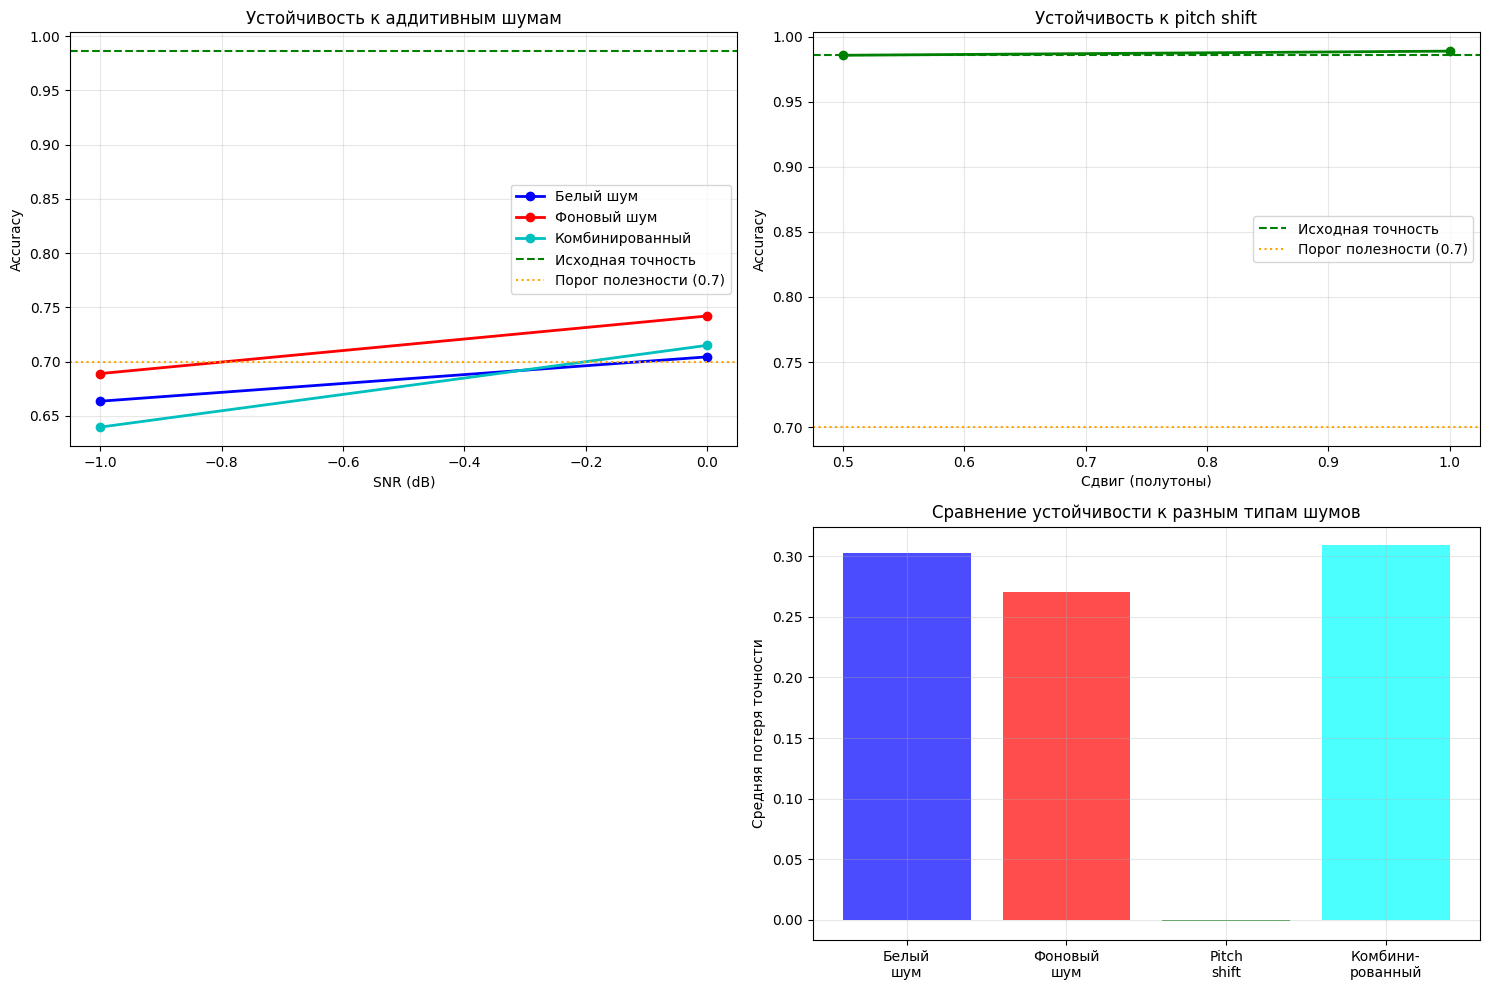


Тестирование устойчивости к шуму завершено.

БЛОК АНАЛИЗА ВИДЕО ЧЕРЕЗ АУДИО
Пытаемся проанализировать видео: /content/drive/MyDrive/video/drone_video_mav1.mp4
Извлекаем аудио из видео...


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Анализируем аудио на наличие дронов...


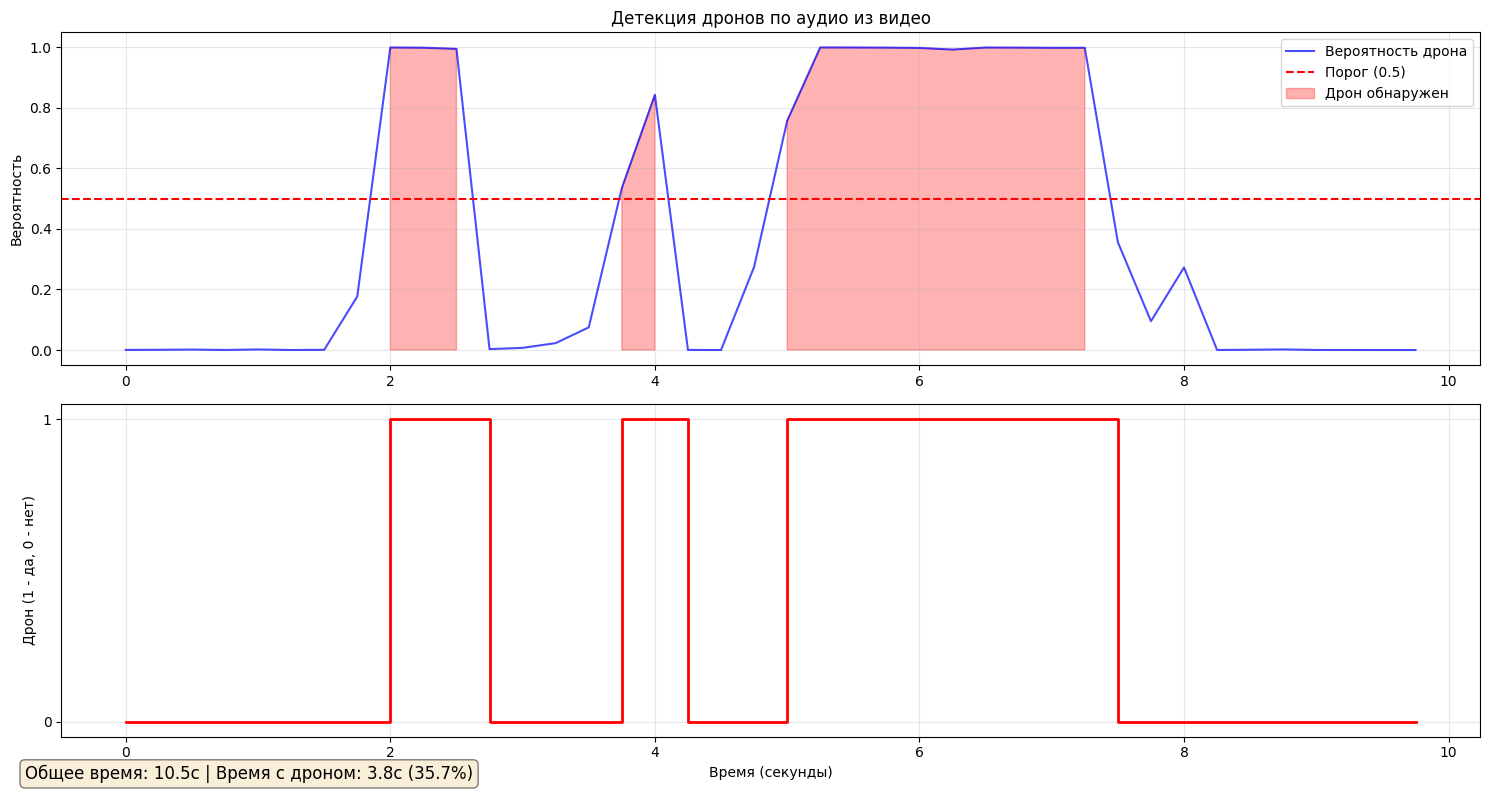

РЕЗУЛЬТАТ: Дрон обнаружен в 35.7% времени видео
Найдено сегментов с дроном: 1
  Сегмент 1: 5.0с - 7.8с (длительность: 2.8с)

Работа завершена!


In [3]:
# @title
# -*- coding: utf-8 -*-
"""Improved Drone Detection Model with Model Loading"""

!pip install torchmetrics
!pip install moviepy pydub
import torch as pt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import torchmetrics
import librosa
import numpy as np
import matplotlib.pyplot as plt
import sys
import random
import os
import time
from google.colab import drive
drive.mount('/content/drive')

# Кэширование
from joblib import Memory
cachedir = '/content/cache/'
memory = Memory(cachedir, verbose=0, compress=True)
memory.clear(warn=False)

# Для воспроизводимости результатов
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
pt.manual_seed(random_seed)
pt.cuda.manual_seed(random_seed)
pt.cuda.manual_seed_all(random_seed)
pt.backends.cudnn.deterministic = True

device = 'cuda' if pt.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Загрузка датасета
!unzip -u "drive/MyDrive/AudioDataset_Detection_Balanced.zip" -d "/content/dataset"
dataset_directory = '/content/dataset/AudioDataset_Detection_Balanced'
duration = 0.5
BATCH_SIZE = 64
NUM_EPOCHS = 18

# =============================================
# ПАРАМЕТРЫ ДЛЯ ЗАГРУЗКИ/СОХРАНЕНИЯ МОДЕЛИ
# =============================================
MODEL_NAME = "drone_detection_model"
MODEL_WEIGHTS_PATH = f'{MODEL_NAME}_weights.pth'
MODEL_CHECKPOINT_PATH = f'{MODEL_NAME}_checkpoint.pth'
GOOGLE_DRIVE_MODEL_PATH = f'/content/drive/MyDrive/{MODEL_NAME}/updated/{MODEL_NAME}_weights.pth'

# Флаг: нужно ли обучать модель заново или загрузить существующую
TRAIN_NEW_MODEL = True  # Установите True, чтобы обучить заново

def check_model_exists():
    """Проверяет, существуют ли сохраненные модели"""
    return os.path.exists(MODEL_WEIGHTS_PATH) or os.path.exists(GOOGLE_DRIVE_MODEL_PATH)

def load_saved_model():
    """Загружает сохраненную модель и чекпоинт"""
    model_path = GOOGLE_DRIVE_MODEL_PATH if os.path.exists(GOOGLE_DRIVE_MODEL_PATH) else MODEL_WEIGHTS_PATH

    print(f"Загружаем модель из: {model_path}")

    # Создаем экземпляр модели
    model = ImprovedCNNNetwork().to(device)

    # Загружаем веса
    model.load_state_dict(pt.load(model_path, map_location=device))
    model.eval()

    # Загружаем чекпоинт, если есть
    history = None
    best_epoch = 0
    original_acc = 0.0

    if os.path.exists(MODEL_CHECKPOINT_PATH):
        checkpoint = pt.load(MODEL_CHECKPOINT_PATH, map_location=device)
        best_epoch = checkpoint.get('epoch', 0)
        original_acc = checkpoint.get('best_accuracy', 0.0)
        history = checkpoint.get('training_history', [])
        print(f"Загружен чекпоинт: эпоха {best_epoch}, точность {original_acc:.4f}")

    return model, best_epoch, original_acc, history

# =============================================
# ФУНКЦИИ ПРЕПРОЦЕССИНГА
# =============================================

def normalize(waveform):
    s = waveform.astype(np.float32) - np.mean(waveform)
    std = np.std(s)
    return s / (std + 1e-8)

def enhanced_melspectrogram(waveform, sr):
    """Улучшенные мел-спектрограммы"""
    spec = librosa.feature.melspectrogram(
        y=waveform, sr=sr,
        n_fft=2048,
        hop_length=256,
        n_mels=128,
        fmin=50,
        fmax=8000,
        pad_mode='reflect'
    )
    spec = librosa.power_to_db(spec, ref=np.max, amin=1e-10)
    spec = (spec - spec.mean()) / (spec.std() + 1e-8)
    return spec

def melspectrogram(waveform, sr):
    return enhanced_melspectrogram(waveform, sr)

def preprocess_file(filename, duration):
    waveform, sr = librosa.load(filename, sr=44100, duration=duration)
    waveform = normalize(waveform)
    spec = melspectrogram(waveform, sr)
    return spec.astype(np.float32)

# =============================================
# ДАТАСЕТЫ И ДАТАЛОАДЕРЫ
# =============================================

class DroneDataset(Dataset):
    def __init__(self, dataset_dir, duration, device):
        files_list = []
        for label_name, label in [("Background", 0), ("Drone", 1)]:
            folder = os.path.join(dataset_dir, label_name)
            for fname in os.listdir(folder):
                if fname.endswith(".wav"):
                    files_list.append((os.path.join(folder, fname), label))
        self.datalist = files_list
        self.duration = duration
        self.device = device

    def __len__(self):
        return len(self.datalist)

    def __getitem__(self, idx):
        spec = preprocess_file(self.datalist[idx][0], self.duration)
        spec = pt.from_numpy(spec[None, ...]).to(self.device)
        label = pt.tensor(float(self.datalist[idx][1]), dtype=pt.float32)
        return spec, label

# Создание датасетов
train_dataset = DroneDataset(os.path.join(dataset_directory, "train"), duration, device)
test_dataset = DroneDataset(os.path.join(dataset_directory, "test"), duration, device)
val_dataset = DroneDataset(os.path.join(dataset_directory, "val"), duration, device)

train_data_size = len(train_dataset)
val_data_size = len(val_dataset)
test_data_size = len(test_dataset)
print(f"Dataset sizes - Train: {train_data_size}, Val: {val_data_size}, Test: {test_data_size}")

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =============================================
# АРХИТЕКТУРА МОДЕЛИ
# =============================================

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 8, 1),
            nn.ReLU(),
            nn.Conv2d(channels // 8, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        ca = self.channel_attention(x)
        return x * ca

class ImprovedCNNNetwork(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout_rate)
        )
        self.att1 = AttentionBlock(16)

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout_rate)
        )
        self.att2 = AttentionBlock(32)

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout_rate)
        )
        self.att3 = AttentionBlock(64)

        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)), nn.Dropout2d(dropout_rate)
        )

        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.att1(x)
        x = self.conv2(x)
        x = self.att2(x)
        x = self.conv3(x)
        x = self.att3(x)
        x = self.conv4(x)
        x = self.flatten(x)
        return self.classifier(x)

# =============================================
# ФУНКЦИИ ДЛЯ ОБУЧЕНИЯ
# =============================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probability_tensor = pt.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - probability_tensor)**self.gamma * BCE_loss
        return focal_loss.mean()

def compute_accuracy(y_pred, y):
    accuracy_metric = torchmetrics.classification.Accuracy(task="binary", threshold=0.5).to(device)
    return accuracy_metric(y_pred, y)

def train_and_validate(model, loss_criterion, optimizer, scheduler, epochs=5):
    history = []
    best_loss = float('inf')
    best_epoch = -1

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = train_acc = 0.0
        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = loss_criterion(outputs, labels)
            loss.backward()
            pt.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            train_acc += compute_accuracy(outputs, labels).item() * inputs.size(0)

        # Validation
        model.eval()
        val_loss = val_acc = 0.0
        with pt.no_grad():
            for inputs, labels in val_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze(-1)
                loss = loss_criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_acc += compute_accuracy(outputs, labels).item() * inputs.size(0)

        # Update scheduler
        scheduler.step()

        # Calculate averages
        avg_train_loss = train_loss / train_data_size
        avg_val_loss = val_loss / val_data_size
        avg_train_acc = train_acc / train_data_size
        avg_val_acc = val_acc / val_data_size

        # Save best model
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_epoch = epoch
            pt.save(model.state_dict(), f'best_model_epoch_{epoch}.pt')

        history.append([avg_train_loss, avg_val_loss, avg_train_acc, avg_val_acc])
        print(f"Epoch {epoch+1}/{epochs}: Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

    return model, history, best_epoch

# =============================================
# ФУНКЦИИ ДЛЯ ОЦЕНКИ МОДЕЛИ
# =============================================

def computeTestSetAccuracy(model, loss_criterion):
    model.eval()
    test_acc = test_loss = 0.0
    true_labels = []
    pred_labels = []

    with pt.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze(-1)
            true_labels.extend(labels.cpu().numpy().astype(int))
            pred_labels.extend((outputs > 0.5).cpu().numpy().astype(int))
            loss = loss_criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            test_acc += compute_accuracy(outputs, labels).item() * inputs.size(0)

    avg_test_acc = test_acc / test_data_size
    avg_test_loss = test_loss / test_data_size
    print(f"Test Accuracy: {avg_test_acc:.5f}, Test Loss: {avg_test_loss:.5f}")

    return avg_test_acc, true_labels, pred_labels

# =============================================
# ФУНКЦИИ ДЛЯ СОХРАНЕНИЯ И ЗАГРУЗКИ МОДЕЛИ
# =============================================

def save_model_complete(model, best_epoch, original_acc, history, model_name="drone_detection_model"):
    """Сохраняет модель полностью с чекпоинтом"""
    # Сохраняем веса модели
    pt.save(model.state_dict(), f'{model_name}_weights.pth')

    # Сохраняем в Google Drive
    pt.save(model.state_dict(), GOOGLE_DRIVE_MODEL_PATH)

    # Сохраняем чекпоинт с дополнительной информацией
    checkpoint = {
        'epoch': best_epoch,
        'model_state_dict': model.state_dict(),
        'best_accuracy': original_acc,
        'training_history': history,
        'model_architecture': 'ImprovedCNNNetwork'
    }
    pt.save(checkpoint, f'{model_name}_checkpoint.pth')

    print(f"✅ Модель успешно сохранена!")
    print(f"📊 Метрики: Accuracy = {original_acc:.4f}, Лучшая эпоха = {best_epoch}")
    print(f"📁 Веса модели: {MODEL_WEIGHTS_PATH}")
    print(f"📁 Копия в Google Drive: {GOOGLE_DRIVE_MODEL_PATH}")
    print(f"📁 Чекпоинт: {MODEL_CHECKPOINT_PATH}")

# =============================================
# ОСНОВНОЙ ПРОЦЕСС: ЗАГРУЗКА ИЛИ ОБУЧЕНИЕ МОДЕЛИ
# =============================================

# Проверяем, существует ли сохраненная модель
model_exists = check_model_exists()

if model_exists and not TRAIN_NEW_MODEL:
    print("="*60)
    print("НАЙДЕНА СОХРАНЕННАЯ МОДЕЛЬ! ЗАГРУЖАЕМ...")
    print("="*60)

    # Загружаем сохраненную модель
    best_model, best_epoch, original_acc, history = load_saved_model()

    # Вычисляем точность на тестовом наборе
    print("\nОценка загруженной модели на тестовом наборе:")
    original_acc, true_labels, pred_labels = computeTestSetAccuracy(best_model, FocalLoss(alpha=0.25, gamma=2.0))

    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    print('F1: {:.5f}'.format(f1_score(true_labels, pred_labels, average="binary")))
    print('Accuracy: {:.5f}'.format(accuracy_score(true_labels, pred_labels)))
    print('Precision: {:.5f}'.format(precision_score(true_labels, pred_labels, average="binary")))
    print('Recall: {:.5f}'.format(recall_score(true_labels, pred_labels, average="binary")))

else:
    print("="*60)
    print("НАЧИНАЕМ ОБУЧЕНИЕ НОВОЙ МОДЕЛИ...")
    print("="*60)

    # ИНИЦИАЛИЗАЦИЯ И ОБУЧЕНИЕ МОДЕЛИ
    print("Инициализация улучшенной модели с Attention...")
    model = ImprovedCNNNetwork().to(device)

    # Проверка архитектуры
    print("Архитектура модели:")
    try:
        summary(model, (1, 128, 87))
    except:
        print("Не удалось вывести summary, продолжаем...")

    # Инициализация оптимизатора и функции потерь
    optimizer = pt.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    scheduler = pt.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    loss_func = FocalLoss(alpha=0.25, gamma=2.0)

    print("Начинаем обучение улучшенной модели...")
    trained_model, history, best_epoch = train_and_validate(model, loss_func, optimizer, scheduler, NUM_EPOCHS)

    # Загрузка лучшей модели
    best_model_path = f'best_model_epoch_{best_epoch}.pt'
    if os.path.exists(best_model_path):
        model.load_state_dict(pt.load(best_model_path))
    best_model = model
    best_model.eval()

    print(f"Лучшая модель загружена из эпохи {best_epoch}")

    # ОЦЕНКА МОДЕЛИ
    print("\nОценка на тестовом наборе:")
    original_acc, true_labels, pred_labels = computeTestSetAccuracy(best_model, loss_func)

    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    print('F1: {:.5f}'.format(f1_score(true_labels, pred_labels, average="binary")))
    print('Accuracy: {:.5f}'.format(accuracy_score(true_labels, pred_labels)))
    print('Precision: {:.5f}'.format(precision_score(true_labels, pred_labels, average="binary")))
    print('Recall: {:.5f}'.format(recall_score(true_labels, pred_labels, average="binary")))

    # СОХРАНЕНИЕ МОДЕЛИ
    print("\n" + "="*60)
    print("СОХРАНЕНИЕ ОБУЧЕННОЙ МОДЕЛИ...")
    print("="*60)
    save_model_complete(best_model, best_epoch, original_acc, history)

# =============================================
# АНАЛИЗ УСТОЙЧИВОСТИ К ШУМАМ (общая часть)
# =============================================

def add_white_noise_proper(signal, snr_db):
    """Добавление белого шума с заданным SNR в dB"""
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

def pitch_shift(signal, sr, n_steps=2.0):
    return librosa.effects.pitch_shift(y=signal, sr=sr, n_steps=n_steps)

def add_background_noise_proper(signal, sr, snr_db, background_files, duration):
    """Добавление фонового шума с заданным SNR в dB"""
    if not background_files:
        return signal

    bg_file = np.random.choice(background_files)
    bg_signal, _ = librosa.load(bg_file, sr=sr, duration=duration)

    if len(bg_signal) < len(signal):
        bg_signal = np.pad(bg_signal, (0, len(signal) - len(bg_signal)), mode='constant')
    else:
        bg_signal = bg_signal[:len(signal)]

    signal_power = np.mean(signal**2)
    bg_power = np.mean(bg_signal**2)

    if bg_power == 0:
        return signal

    snr_linear = 10**(snr_db / 10)
    desired_bg_power = signal_power / snr_linear
    scale_factor = np.sqrt(desired_bg_power / bg_power)

    return signal + bg_signal * scale_factor

def combined_noise(signal, sr, snr_db, background_files, pitch_steps=2.0):
    """Комбинированный шум: pitch shift + белый шум + фоновый шум"""
    if pitch_steps != 0.0:
        signal = pitch_shift(signal, sr, n_steps=abs(pitch_steps))
    signal = add_white_noise_proper(signal, snr_db)
    if background_files and len(background_files) > 0:
        signal = add_background_noise_proper(signal, sr, snr_db, background_files, len(signal)/sr)
    return signal

# Загрузка фоновых файлов
background_files = []
bg_dir = os.path.join(dataset_directory, "train", "Background")
for fname in os.listdir(bg_dir):
    if fname.endswith(".wav"):
        background_files.append(os.path.join(bg_dir, fname))

class NoisyDroneDataset(Dataset):
    def __init__(self, original_dataset, noise_type, noise_param, sr=44100):
        self.orig = original_dataset
        self.noise_type = noise_type
        self.noise_param = noise_param
        self.sr = sr
        self.bg_files = background_files

    def __len__(self):
        return len(self.orig)

    def __getitem__(self, idx):
        path, label = self.orig.datalist[idx]
        clean_wave, _ = librosa.load(path, sr=self.sr, duration=duration)
        clean_wave = normalize(clean_wave)

        if self.noise_type == 'white':
            noisy_wave = add_white_noise_proper(clean_wave, self.noise_param)
        elif self.noise_type == 'background':
            noisy_wave = add_background_noise_proper(clean_wave, self.sr, self.noise_param, self.bg_files, duration)
        elif self.noise_type == 'pitch_shift':
            noisy_wave = pitch_shift(clean_wave, self.sr, n_steps=self.noise_param)
        elif self.noise_type == 'combined':
            pitch_steps = abs(self.noise_param) * 0.4
            noisy_wave = combined_noise(clean_wave, self.sr, self.noise_param, self.bg_files, pitch_steps)
        else:
            raise ValueError(f"Unknown noise type: {self.noise_type}")

        spec = melspectrogram(noisy_wave, self.sr).astype(np.float32)
        spec = pt.from_numpy(spec[None, ...]).to(device)
        label = pt.tensor(float(label), dtype=pt.float32)
        return spec, label

def test_model_on_noisy_data(model, test_dataset, noise_type, noise_level):
    noisy_ds = NoisyDroneDataset(test_dataset, noise_type, noise_level)
    loader = DataLoader(noisy_ds, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    true, pred = [], []
    with pt.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            out = model(inputs).squeeze(-1)
            preds = (out > 0.5).float().cpu().numpy()
            true.extend(labels.numpy().astype(int))
            pred.extend(preds.astype(int))
    return accuracy_score(true, pred)

def calculate_robustness_metrics(original_acc, noisy_accuracies, noise_params):
    accuracy_drop = [original_acc - acc for acc in noisy_accuracies]
    robustness_threshold = None
    for i, acc in enumerate(noisy_accuracies):
        if acc < 0.7:
            robustness_threshold = noise_params[i]
            break
    return {
        'accuracy_drop': accuracy_drop,
        'robustness_threshold': robustness_threshold,
        'mean_accuracy_drop': np.mean(accuracy_drop)
    }

# Уровни шума для тестирования
WHITE_NOISE_LEVELS = [0,-1]
BACKGROUND_NOISE_LEVELS = [0,-1]
PITCH_LEVELS = [0.5, 1]
COMBINED_LEVELS = [0,-1]

print(f"\n=== Оригинал: Accuracy = {original_acc:.5f} ===")

print("\n" + "="*80)
print(f"{'Тип шума':<15} {'Параметр':<10} {'Accuracy':<12} {'Потеря Accuracy':<15}")
print("-"*80)

# Тестирование на разных типах шумов
noise_results = {}

for noise_type, levels in [('white', WHITE_NOISE_LEVELS),
                          ('background', BACKGROUND_NOISE_LEVELS),
                          ('pitch_shift', PITCH_LEVELS),
                          ('combined', COMBINED_LEVELS)]:

    accuracies = []
    for level in levels:
        acc = test_model_on_noisy_data(best_model, test_dataset, noise_type, level)
        accuracies.append(acc)
        loss = original_acc - acc
        param_str = f'{level} dB' if noise_type in ['white', 'background', 'combined'] else f'{level} st' if noise_type == 'pitch_shift' else f'{level}s'
        print(f"{noise_type:<15} {param_str:<10} {acc:<12.5f} {loss:<15.5f}")

    noise_results[noise_type] = accuracies
    metrics = calculate_robustness_metrics(original_acc, accuracies, levels)
    print(f"Порог устойчивости к {noise_type}: {metrics['robustness_threshold']}")

# Визуализация результатов
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(WHITE_NOISE_LEVELS, noise_results['white'], 'bo-', label='Белый шум', linewidth=2)
plt.plot(BACKGROUND_NOISE_LEVELS, noise_results['background'], 'ro-', label='Фоновый шум', linewidth=2)
plt.plot(COMBINED_LEVELS, noise_results['combined'], 'co-', label='Комбинированный', linewidth=2)
plt.axhline(y=original_acc, color='g', linestyle='--', label='Исходная точность')
plt.axhline(y=0.7, color='orange', linestyle=':', label='Порог полезности (0.7)')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Устойчивость к аддитивным шумам')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(PITCH_LEVELS, noise_results['pitch_shift'], 'go-', linewidth=2)
plt.axhline(y=original_acc, color='g', linestyle='--', label='Исходная точность')
plt.axhline(y=0.7, color='orange', linestyle=':', label='Порог полезности (0.7)')
plt.xlabel('Сдвиг (полутоны)')
plt.ylabel('Accuracy')
plt.title('Устойчивость к pitch shift')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
losses = [np.mean([original_acc - acc for acc in noise_results[nt]]) for nt in ['white', 'background', 'pitch_shift', 'combined']]
types = ['Белый\nшум', 'Фоновый\nшум', 'Pitch\nshift', 'Комбини-\nрованный']
plt.bar(types, losses, color=['blue', 'red', 'green', 'cyan'], alpha=0.7)
plt.ylabel('Средняя потеря точности')
plt.title('Сравнение устойчивости к разным типам шумов')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('robustness_analysis_detection.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nТестирование устойчивости к шуму завершено.")

# =============================================
# БЛОК АНАЛИЗА ВИДЕО ЧЕРЕЗ АУДИО
# =============================================

def extract_audio_from_video(video_path, output_audio_path):
    """Извлечение аудиодорожки из видео"""
    try:
        from moviepy.editor import VideoFileClip
        video = VideoFileClip(video_path)
        audio = video.audio
        audio.write_audiofile(output_audio_path, verbose=False, logger=None)
        video.close()
        return True
    except Exception as e:
        print(f"Ошибка извлечения аудио: {e}")
        return False

def analyze_audio_for_drones(audio_path, model, duration=0.5, overlap=0.25):
    """
    Анализ аудиофайла на наличие дронов с скользящим окном
    """
    # Загружаем аудио
    audio, sr = librosa.load(audio_path, sr=44100)

    # Параметры окон
    window_size = int(duration * sr)
    hop_size = int((duration - overlap) * sr)

    results = []
    timestamps = []

    # Обрабатываем аудио окнами
    for start in range(0, len(audio) - window_size, hop_size):
        end = start + window_size
        audio_chunk = audio[start:end]

        # Препроцессинг как в обучении
        audio_chunk = normalize(audio_chunk)
        spec = melspectrogram(audio_chunk, sr).astype(np.float32)
        spec = pt.from_numpy(spec[None, None, ...]).to(device)  # [1, 1, 64, 44]

        # Предсказание
        with pt.no_grad():
            prediction = model(spec).item()

        timestamp = start / sr
        results.append(prediction)
        timestamps.append(timestamp)

    return {
        'timestamps': timestamps,
        'predictions': results,
        'audio_length': len(audio) / sr
    }

def process_video_for_drone_detection(video_path, model, duration=0.5, overlap=0.25):
    """
    Полный пайплайн: видео -> аудио -> анализ нейросетью
    """
    # Временный файл для аудио
    temp_audio = "temp_audio.wav"

    # 1. Извлекаем аудио
    print("Извлекаем аудио из видео...")
    if not extract_audio_from_video(video_path, temp_audio):
        return None

    # 2. Анализируем аудио
    print("Анализируем аудио на наличие дронов...")
    results = analyze_audio_for_drones(temp_audio, model, duration, overlap)

    # 3. Удаляем временный файл
    import os
    if os.path.exists(temp_audio):
        os.remove(temp_audio)

    return results

def plot_drone_detection_results(results, threshold=0.5):
    """
    Визуализация результатов детекции дронов во времени
    """
    timestamps = results['timestamps']
    predictions = results['predictions']

    plt.figure(figsize=(15, 8))

    # График вероятностей
    plt.subplot(2, 1, 1)
    plt.plot(timestamps, predictions, 'b-', alpha=0.7, label='Вероятность дрона')
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Порог ({threshold})')
    plt.fill_between(timestamps, 0, predictions,
                    where=[p > threshold for p in predictions],
                    color='red', alpha=0.3, label='Дрон обнаружен')
    plt.ylabel('Вероятность')
    plt.title('Детекция дронов по аудио из видео')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Бинарная детекция
    plt.subplot(2, 1, 2)
    binary_detection = [1 if p > threshold else 0 for p in predictions]
    plt.step(timestamps, binary_detection, 'r-', where='post', linewidth=2)
    plt.ylabel('Дрон (1 - да, 0 - нет)')
    plt.xlabel('Время (секунды)')
    plt.yticks([0, 1])
    plt.grid(True, alpha=0.3)

    # Статистика
    total_time = results['audio_length']
    drone_time = sum(binary_detection) * (timestamps[1] - timestamps[0])
    drone_percentage = (drone_time / total_time) * 100

    plt.figtext(0.02, 0.02,
                f"Общее время: {total_time:.1f}с | "
                f"Время с дроном: {drone_time:.1f}с ({drone_percentage:.1f}%)",
                fontsize=12, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig('video_audio_detection.png', dpi=200, bbox_inches='tight')
    plt.show()

    return drone_percentage

def smooth_predictions(predictions, window_size=5):
    """Сглаживание предсказаний скользящим средним"""
    return np.convolve(predictions, np.ones(window_size)/window_size, mode='same')

def advanced_detection_logic(predictions, timestamps, threshold=0.5, min_duration=1.0):
    """
    Продвинутая логика детекции:
    - Игнорировать короткие срабатывания
    - Объединять близкие детекции
    """
    # Сглаживание
    smoothed = smooth_predictions(predictions)

    # Бинаризация
    binary = [1 if p > threshold else 0 for p in smoothed]

    # Поиск сегментов
    segments = []
    in_segment = False
    segment_start = 0

    for i, (ts, det) in enumerate(zip(timestamps, binary)):
        if det and not in_segment:
            in_segment = True
            segment_start = ts
        elif not det and in_segment:
            in_segment = False
            segment_end = ts
            duration = segment_end - segment_start
            if duration >= min_duration:
                segments.append((segment_start, segment_end, duration))

    return segments

# =============================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ С ВИДЕО
# =============================================

print("\n" + "="*60)
print("БЛОК АНАЛИЗА ВИДЕО ЧЕРЕЗ АУДИО")
print("="*60)

# Загружаем обученную модель (если еще не загружена)
best_model.eval()

# Пример 1: Анализ видео файла
video_path = "/content/drive/MyDrive/video/drone_video_mav1.mp4"  # укажите путь к вашему видео

try:
    print(f"Пытаемся проанализировать видео: {video_path}")
    results = process_video_for_drone_detection(video_path, best_model)

    if results:
        drone_percentage = plot_drone_detection_results(results)
        print(f"РЕЗУЛЬТАТ: Дрон обнаружен в {drone_percentage:.1f}% времени видео")

        # Продвинутый анализ
        segments = advanced_detection_logic(results['predictions'], results['timestamps'])
        print(f"Найдено сегментов с дроном: {len(segments)}")
        for i, (start, end, duration) in enumerate(segments):
            print(f"  Сегмент {i+1}: {start:.1f}с - {end:.1f}с (длительность: {duration:.1f}с)")
    else:
        print("Не удалось обработать видео")

except Exception as e:
    print(f"Ошибка при обработке видео: {e}")
    print("Убедитесь, что:")
    print("1. Путь к видео файлу правильный")
    print("2. Файл существует")
    print("3. Формат видео поддерживается (mp4, avi, mov)")

print("\nРабота завершена!")

In [ ]:
!pip install tabulate

In [ ]:
# @title
def visualize_complete_results(results, clean_metrics):
    """Визуализация всех метрик для всех типов шумов"""
    fig = plt.figure(figsize=(20, 16))

    # Определим цвета и маркеры для разных типов шумов
    noise_configs = {
        'white': {'color': 'blue', 'marker': 'o', 'label': 'Белый шум'},
        'background': {'color': 'red', 'marker': 's', 'label': 'Фоновый шум'},
        'combined': {'color': 'cyan', 'marker': '^', 'label': 'Комбинированный'},
        'pitch_shift': {'color': 'green', 'marker': 'D', 'label': 'Pitch Shift'}
    }

    # График 1: Accuracy для аддитивных шумов (SNR)
    ax1 = plt.subplot(3, 2, 1)
    for noise_type in ['white', 'background', 'combined']:
        if noise_type in results and noise_type != 'clean':
            config = noise_configs[noise_type]
            levels = list(results[noise_type].keys())
            # Проверяем, что уровни числовые для сортировки
            try:
                sorted_levels = sorted(levels, key=lambda x: float(x) if isinstance(x, (int, float)) else x)
            except:
                sorted_levels = levels

            accuracies = [results[noise_type][l]['accuracy'] for l in sorted_levels]
            # ИСПРАВЛЕНИЕ: правильный формат строки
            ax1.plot(sorted_levels, accuracies,
                    color=config['color'],
                    marker=config['marker'],
                    linestyle='-',
                    label=config['label'],
                    linewidth=2)

    ax1.axhline(y=clean_metrics['accuracy'], color='green', linestyle='--',
                label='Чистый сигнал', linewidth=2)
    ax1.axhline(y=0.7, color='orange', linestyle=':',
                label='Порог полезности', linewidth=1.5)
    ax1.set_xlabel('SNR (dB)')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy для аддитивных шумов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # График 2: Precision для аддитивных шумов
    ax2 = plt.subplot(3, 2, 2)
    for noise_type in ['white', 'background', 'combined']:
        if noise_type in results and noise_type != 'clean':
            config = noise_configs[noise_type]
            levels = list(results[noise_type].keys())
            try:
                sorted_levels = sorted(levels, key=lambda x: float(x) if isinstance(x, (int, float)) else x)
            except:
                sorted_levels = levels

            precisions = [results[noise_type][l]['precision'] for l in sorted_levels]
            ax2.plot(sorted_levels, precisions,
                    color=config['color'],
                    marker=config['marker'],
                    linestyle='-',
                    label=config['label'],
                    linewidth=2)

    ax2.axhline(y=clean_metrics['precision'], color='green', linestyle='--',
                label='Чистый сигнал', linewidth=2)
    ax2.set_xlabel('SNR (dB)')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision для аддитивных шумов')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # График 3: Recall для аддитивных шумов
    ax3 = plt.subplot(3, 2, 3)
    for noise_type in ['white', 'background', 'combined']:
        if noise_type in results and noise_type != 'clean':
            config = noise_configs[noise_type]
            levels = list(results[noise_type].keys())
            try:
                sorted_levels = sorted(levels, key=lambda x: float(x) if isinstance(x, (int, float)) else x)
            except:
                sorted_levels = levels

            recalls = [results[noise_type][l]['recall'] for l in sorted_levels]
            ax3.plot(sorted_levels, recalls,
                    color=config['color'],
                    marker=config['marker'],
                    linestyle='-',
                    label=config['label'],
                    linewidth=2)

    ax3.axhline(y=clean_metrics['recall'], color='green', linestyle='--',
                label='Чистый сигнал', linewidth=2)
    ax3.set_xlabel('SNR (dB)')
    ax3.set_ylabel('Recall')
    ax3.set_title('Recall для аддитивных шумов')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # График 4: F1-score для аддитивных шумов
    ax4 = plt.subplot(3, 2, 4)
    for noise_type in ['white', 'background', 'combined']:
        if noise_type in results and noise_type != 'clean':
            config = noise_configs[noise_type]
            levels = list(results[noise_type].keys())
            try:
                sorted_levels = sorted(levels, key=lambda x: float(x) if isinstance(x, (int, float)) else x)
            except:
                sorted_levels = levels

            f1_scores = [results[noise_type][l]['f1'] for l in sorted_levels]
            ax4.plot(sorted_levels, f1_scores,
                    color=config['color'],
                    marker=config['marker'],
                    linestyle='-',
                    label=config['label'],
                    linewidth=2)

    ax4.axhline(y=clean_metrics['f1'], color='green', linestyle='--',
                label='Чистый сигнал', linewidth=2)
    ax4.axhline(y=0.7, color='orange', linestyle=':',
                label='Порог полезности', linewidth=1.5)
    ax4.set_xlabel('SNR (dB)')
    ax4.set_ylabel('F1-score')
    ax4.set_title('F1-score для аддитивных шумов')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # График 5: Accuracy для pitch_shift
    ax5 = plt.subplot(3, 2, 5)
    if 'pitch_shift' in results and results['pitch_shift'] != 'clean':
        config = noise_configs['pitch_shift']
        levels = list(results['pitch_shift'].keys())
        try:
            sorted_levels = sorted(levels, key=lambda x: float(x) if isinstance(x, (int, float)) else x)
        except:
            sorted_levels = levels

        accuracies = [results['pitch_shift'][l]['accuracy'] for l in sorted_levels]
        ax5.plot(sorted_levels, accuracies,
                color=config['color'],
                marker=config['marker'],
                linestyle='-',
                label=config['label'],
                linewidth=2)

        ax5.axhline(y=clean_metrics['accuracy'], color='green', linestyle='--',
                    label='Чистый сигнал', linewidth=2)
        ax5.axhline(y=0.7, color='orange', linestyle=':',
                    label='Порог полезности', linewidth=1.5)
        ax5.set_xlabel('Сдвиг (полутоны)')
        ax5.set_ylabel('Accuracy')
        ax5.set_title('Accuracy для Pitch Shift')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'Нет данных для Pitch Shift',
                ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.set_title('Accuracy для Pitch Shift')

    plt.tight_layout()
    plt.savefig('complete_robustness_analysis.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Создаем второй график для сводной таблицы потерь
    fig2, ax7 = plt.subplots(figsize=(12, 8))

    # Считаем средние потери по метрикам для каждого типа шума
    noise_types_list = ['white', 'background', 'pitch_shift', 'combined']
    metric_losses = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for noise_type in noise_types_list:
        if noise_type in results and noise_type != 'clean' and results[noise_type]:
            acc_loss = np.mean([clean_metrics['accuracy'] - results[noise_type][l]['accuracy']
                              for l in results[noise_type].keys()])
            prec_loss = np.mean([clean_metrics['precision'] - results[noise_type][l]['precision']
                               for l in results[noise_type].keys()])
            rec_loss = np.mean([clean_metrics['recall'] - results[noise_type][l]['recall']
                              for l in results[noise_type].keys()])
            f1_loss = np.mean([clean_metrics['f1'] - results[noise_type][l]['f1']
                             for l in results[noise_type].keys()])

            metric_losses['accuracy'].append(acc_loss)
            metric_losses['precision'].append(prec_loss)
            metric_losses['recall'].append(rec_loss)
            metric_losses['f1'].append(f1_loss)
        else:
            metric_losses['accuracy'].append(0)
            metric_losses['precision'].append(0)
            metric_losses['recall'].append(0)
            metric_losses['f1'].append(0)

    x = np.arange(len(noise_types_list))
    width = 0.2

    colors = ['blue', 'red', 'green', 'purple']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

    for i, (metric, color) in enumerate(zip(['accuracy', 'precision', 'recall', 'f1'], colors)):
        ax7.bar(x + (i-1.5)*width, metric_losses[metric], width,
                label=metric_names[i], color=color, alpha=0.7)

    ax7.set_xlabel('Тип шума')
    ax7.set_ylabel('Средняя потеря метрики')
    ax7.set_title('Сравнение устойчивости метрик к разным шумам')
    ax7.set_xticks(x)
    ax7.set_xticklabels(['Белый\nшум', 'Фоновый\nшум', 'Pitch\nshift', 'Комбини-\nрованный'])
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('metric_losses_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Третий график: метрики на чистом сигнале
    fig3, ax8 = plt.subplots(figsize=(10, 6))

    metrics_clean = [clean_metrics['accuracy'], clean_metrics['precision'],
                     clean_metrics['recall'], clean_metrics['f1']]
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = ['blue', 'red', 'green', 'purple']

    bars = ax8.bar(metric_names, metrics_clean, color=colors, alpha=0.7)
    ax8.set_ylabel('Значение метрики')
    ax8.set_title('Метрики на чистом сигнале')
    ax8.set_ylim([0, 1.05])
    ax8.grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for bar, value in zip(bars, metrics_clean):
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('clean_signal_metrics.png', dpi=200, bbox_inches='tight')
    plt.show()

    return results

In [ ]:
# @title
# =============================================
# ПОЛНЫЙ АНАЛИЗ С КРАСИВЫМИ ТАБЛИЦАМИ В КОНСОЛИ
# =============================================

from tabulate import tabulate
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def calculate_all_metrics(true_labels, pred_labels):
    """Расчет всех метрик классификации"""
    accuracy = accuracy_score(true_labels, pred_labels)
    precision = precision_score(true_labels, pred_labels, average='binary', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='binary', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='binary', zero_division=0)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def test_model_complete_analysis(model, test_dataset, noise_type, noise_param):
    """Полный анализ модели с возвратом всех метрик"""
    noisy_ds = NoisyDroneDataset(test_dataset, noise_type, noise_param)
    loader = DataLoader(noisy_ds, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    true, pred = [], []
    all_probs = []

    with pt.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            out = model(inputs).squeeze(-1)
            probs = out.cpu().numpy()
            preds = (out > 0.5).float().cpu().numpy()
            true.extend(labels.numpy().astype(int))
            pred.extend(preds.astype(int))
            all_probs.extend(probs)

    metrics = calculate_all_metrics(true, pred)

    # Дополнительные метрики
    if len(set(true)) > 1:  # Проверяем, есть ли оба класса
        cm = confusion_matrix(true, pred)
        if cm.size == 4:
            tn, fp, fn, tp = cm.ravel()
        else:
            tn, fp, fn, tp = 0, 0, 0, 0
    else:
        cm = np.array([[0, 0], [0, 0]])
        tn, fp, fn, tp = 0, 0, 0, 0

    metrics.update({
        'confusion_matrix': cm,
        'true_positive': tp,
        'true_negative': tn,
        'false_positive': fp,
        'false_negative': fn,
        'total_samples': len(true)
    })

    return metrics

def print_metrics_table(metrics_dict, title="Метрики классификации"):
    """Красивая таблица с метриками с использованием tabulate"""
    # Основные метрики
    main_metrics = [
        ["Accuracy", f"{metrics_dict['accuracy']:.5f}", "Доля правильных предсказаний"],
        ["Precision", f"{metrics_dict['precision']:.5f}", "Точность положительных предсказаний"],
        ["Recall", f"{metrics_dict['recall']:.5f}", "Полнота обнаружения дронов"],
        ["F1-Score", f"{metrics_dict['f1']:.5f}", "Среднее гармоническое precision и recall"]
    ]

    print(f"\n{'='*80}")
    print(f"{title:^80}")
    print(f"{'='*80}")

    print(tabulate(main_metrics,
                   headers=["Метрика", "Значение", "Описание"],
                   tablefmt="grid",
                   stralign="left",
                   numalign="center",
                   floatfmt=".5f"))

    # Матрица ошибок
    if 'confusion_matrix' in metrics_dict:
        print(f"\n{'Матрица ошибок (Confusion Matrix)':^80}")
        print(f"{'─'*80}")

        confusion_data = [
            ["True Positive (TP)", metrics_dict['true_positive'], "Правильно обнаруженные дроны"],
            ["True Negative (TN)", metrics_dict['true_negative'], "Правильно обнаруженные фоновые звуки"],
            ["False Positive (FP)", metrics_dict['false_positive'], "Ложные срабатывания (фоновые → дрон)"],
            ["False Negative (FN)", metrics_dict['false_negative'], "Пропущенные дроны (дрон → фон)"]
        ]

        print(tabulate(confusion_data,
                       headers=["Тип ошибки", "Количество", "Описание"],
                       tablefmt="simple_grid",
                       stralign="left",
                       numalign="center"))

    print(f"{'='*80}")

def analyze_noise_impact_complete(model, test_dataset, noise_types=None):
    """Полный анализ влияния всех типов шумов со всеми метриками"""
    if noise_types is None:
        noise_types = ['white', 'background', 'pitch_shift', 'combined']

    # Уровни шумов для каждого типа
    noise_levels = {
        'white': WHITE_NOISE_LEVELS,
        'background': BACKGROUND_NOISE_LEVELS,
        'pitch_shift': PITCH_LEVELS,
        'combined': COMBINED_LEVELS
    }

    noise_names = {
        'white': 'Белый шум',
        'background': 'Фоновый шум',
        'pitch_shift': 'Pitch Shift',
        'combined': 'Комбинированный шум'
    }

    # Сначала тестируем на чистом сигнале (без шума)
    print("\n" + "="*100)
    print("АНАЛИЗ НА ЧИСТОМ СИГНАЛЕ (БЕЗ ШУМОВ)".center(100))
    print("="*100)

    # Тестируем на оригинальном тестовом наборе
    model.eval()
    true_labels = []
    pred_labels = []

    with pt.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze(-1)
            true_labels.extend(labels.cpu().numpy().astype(int))
            pred_labels.extend((outputs > 0.5).cpu().numpy().astype(int))

    clean_metrics = calculate_all_metrics(true_labels, pred_labels)
    print_metrics_table(clean_metrics, "РЕЗУЛЬТАТЫ НА ЧИСТОМ СИГНАЛЕ")

    # Сохраняем метрики для чистого сигнала
    results = {'clean': clean_metrics}

    # Тестируем для каждого типа шума
    for noise_type in noise_types:
        print(f"\n" + "="*100)
        print(f"АНАЛИЗ ДЛЯ: {noise_names[noise_type]}".center(100))
        print("="*100)

        metrics_by_level = {}

        # Подготовка данных для таблицы
        table_data = []

        for level in noise_levels[noise_type]:
            # Форматируем параметр для отображения
            if noise_type in ['white', 'background', 'combined']:
                param_str = f"{level} dB"
            elif noise_type == 'pitch_shift':
                param_str = f"{level} полутонов"

            # Получаем все метрики
            metrics = test_model_complete_analysis(model, test_dataset, noise_type, level)
            metrics_by_level[level] = metrics

            # Сравнение с чистым сигналом
            acc_drop = clean_metrics['accuracy'] - metrics['accuracy']

            # Добавляем строку в таблицу
            table_data.append([
                param_str,
                f"{metrics['accuracy']:.5f}",
                f"{metrics['precision']:.5f}",
                f"{metrics['recall']:.5f}",
                f"{metrics['f1']:.5f}",
                f"{acc_drop:.5f}"
            ])

        # Выводим красивую таблицу
        headers = ["Уровень шума", "Accuracy", "Precision", "Recall", "F1-Score", "Потеря Accuracy"]

        print(f"\n{noise_names[noise_type]}")
        print(tabulate(table_data,
                       headers=headers,
                       tablefmt="grid",
                       stralign="center",
                       numalign="center",
                       floatfmt=".5f"))

        results[noise_type] = metrics_by_level

    return results, clean_metrics

def create_summary_table(results, clean_metrics):
    """Создание сводной таблицы результатов"""
    print("\n" + "="*120)
    print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ".center(120))
    print("="*120)

    # Подготовка данных для таблицы
    table_data = []

    # Сначала чистая метрика
    table_data.append([
        "Чистый сигнал",
        "-",
        f"{clean_metrics['accuracy']:.5f}",
        f"{clean_metrics['precision']:.5f}",
        f"{clean_metrics['recall']:.5f}",
        f"{clean_metrics['f1']:.5f}",
        "0.00000"
    ])

    noise_names = {
        'white': 'Белый шум',
        'background': 'Фоновый шум',
        'pitch_shift': 'Pitch Shift',
        'combined': 'Комбинированный шум'
    }

    # Для каждого типа шума и уровня
    for noise_type in ['white', 'background', 'pitch_shift', 'combined']:
        if noise_type in results and noise_type != 'clean':
            for level in sorted(results[noise_type].keys()):
                metrics = results[noise_type][level]

                # Форматирование уровня шума
                if noise_type in ['white', 'background', 'combined']:
                    level_str = f"{level} dB"
                elif noise_type == 'pitch_shift':
                    level_str = f"{level} st"

                # Потеря accuracy
                acc_drop = clean_metrics['accuracy'] - metrics['accuracy']

                table_data.append([
                    noise_names[noise_type],
                    level_str,
                    f"{metrics['accuracy']:.5f}",
                    f"{metrics['precision']:.5f}",
                    f"{metrics['recall']:.5f}",
                    f"{metrics['f1']:.5f}",
                    f"{acc_drop:.5f}"
                ])

    headers = ["Тип шума", "Уровень", "Accuracy", "Precision", "Recall", "F1-Score", "ΔAccuracy"]

    print(tabulate(table_data,
                   headers=headers,
                   tablefmt="grid",
                   stralign="center",
                   numalign="center",
                   floatfmt=".5f"))

    print("="*120)

def analyze_robustness_thresholds(results, clean_metrics):
    """Анализ порогов устойчивости в виде таблицы"""
    print("\n" + "="*80)
    print("АНАЛИЗ ПОРОГОВ УСТОЙЧИВОСТИ".center(80))
    print("="*80)

    threshold_data = []

    for noise_type in ['white', 'background', 'combined']:
        if noise_type in results:
            # Находим порог, где accuracy падает ниже 0.7
            threshold_level = None
            critical_level = None

            for level in sorted(results[noise_type].keys()):
                if results[noise_type][level]['accuracy'] < 0.7:
                    if noise_type in ['white', 'background', 'combined']:
                        threshold_level = f"{level} dB"
                        critical_level = f"{level} dB"
                    else:
                        threshold_level = f"{level}"
                        critical_level = f"{level}"
                    break

            noise_name = {
                'white': 'Белый шум',
                'background': 'Фоновый шум',
                'combined': 'Комбинированный шум'
            }.get(noise_type, noise_type)

            if threshold_level:
                status = f"Порог: {threshold_level}"
            else:
                status = "Устойчив ко всем уровням"
                critical_level = "> max"

            # Добавляем метрики при критическом уровне
            if threshold_level and 'dB' in threshold_level:
                level_value = float(threshold_level.replace(' dB', ''))
                if level_value in results[noise_type]:
                    metrics = results[noise_type][level_value]
                    threshold_data.append([
                        noise_name,
                        critical_level,
                        f"{metrics['accuracy']:.3f}",
                        f"{metrics['precision']:.3f}",
                        f"{metrics['recall']:.3f}",
                        f"{metrics['f1']:.3f}",
                        status
                    ])
                else:
                    threshold_data.append([noise_name, critical_level, "-", "-", "-", "-", status])
            else:
                threshold_data.append([noise_name, critical_level, "-", "-", "-", "-", status])

    headers = ["Тип шума", "Критич. уровень", "Accuracy", "Precision", "Recall", "F1", "Статус"]

    if threshold_data:
        print(tabulate(threshold_data,
                       headers=headers,
                       tablefmt="grid",
                       stralign="center",
                       numalign="center"))
    else:
        print("Данные для анализа порогов отсутствуют.")

    print("="*80)

def print_performance_summary(clean_metrics, results):
    """Итоговая сводка производительности в виде таблицы"""
    print("\n" + "="*80)
    print("ИТОГОВАЯ СВОДКА ПРОИЗВОДИТЕЛЬНОСТИ".center(80))
    print("="*80)

    summary_data = []

    # Средние потери для каждого типа шума
    for noise_type in ['white', 'background', 'pitch_shift', 'combined']:
        if noise_type in results and noise_type != 'clean':
            # Вычисляем средние метрики для этого типа шума
            acc_values = [results[noise_type][l]['accuracy'] for l in results[noise_type].keys()]
            prec_values = [results[noise_type][l]['precision'] for l in results[noise_type].keys()]
            rec_values = [results[noise_type][l]['recall'] for l in results[noise_type].keys()]
            f1_values = [results[noise_type][l]['f1'] for l in results[noise_type].keys()]

            avg_acc = np.mean(acc_values)
            avg_prec = np.mean(prec_values)
            avg_rec = np.mean(rec_values)
            avg_f1 = np.mean(f1_values)

            noise_name = {
                'white': 'Белый шум',
                'background': 'Фоновый шум',
                'pitch_shift': 'Pitch Shift',
                'combined': 'Комбинированный'
            }[noise_type]

            summary_data.append([
                noise_name,
                f"{avg_acc:.4f}",
                f"{avg_prec:.4f}",
                f"{avg_rec:.4f}",
                f"{avg_f1:.4f}"
            ])

    # Добавляем чистый сигнал
    summary_data.insert(0, [
        "Чистый сигнал",
        f"{clean_metrics['accuracy']:.4f}",
        f"{clean_metrics['precision']:.4f}",
        f"{clean_metrics['recall']:.4f}",
        f"{clean_metrics['f1']:.4f}"
    ])

    headers = ["Тип сигнала", "Avg Accuracy", "Avg Precision", "Avg Recall", "Avg F1-Score"]

    print(tabulate(summary_data,
                   headers=headers,
                   tablefmt="grid",
                   stralign="center",
                   numalign="center",
                   floatfmt=".4f"))

    print("="*80)

# =============================================
# ЗАПУСК ПОЛНОГО АНАЛИЗА
# =============================================

print("\n" + "="*100)
print("ПОЛНЫЙ АНАЛИЗ УСТОЙЧИВОСТИ МОДЕЛИ К ШУМАМ".center(100))
print("="*100)

# Проверяем, что модель обучена
if 'best_model' not in locals():
    print("Модель не обучена! Сначала обучите модель.")
else:
    # Запускаем полный анализ
    print("\nНачинаем анализ...")
    results, clean_metrics = analyze_noise_impact_complete(best_model, test_dataset)

    # Выводим сводную таблицу
    create_summary_table(results, clean_metrics)

    # Анализ порогов устойчивости
    analyze_robustness_thresholds(results, clean_metrics)

    # Итоговая сводка
    print_performance_summary(clean_metrics, results)

    # Визуализация результатов (графики)
    print("\n" + "="*100)
    print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ".center(100))
    print("="*100)

    # Графики (оставляем предыдущую функцию визуализации)
    visualize_complete_results(results, clean_metrics)

    print("\n" + "="*100)
    print("ПОЛНЫЙ АНАЛИЗ ЗАВЕРШЕН! ✅".center(100))
    print("="*100)